In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("archive/Personal_Finance_Dataset.csv")

In [14]:
df.shape

(1500, 5)

In [4]:
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB


## 1. Categorical Data

<Axes: xlabel='count', ylabel='Category'>

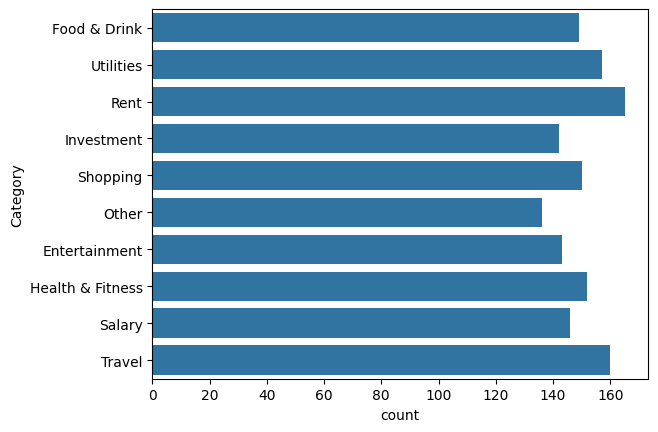

In [13]:
# sns.countplot(x = df['Category'])
# plt.xticks(rotation=30)

sns.countplot(df['Category'])

<Axes: ylabel='count'>

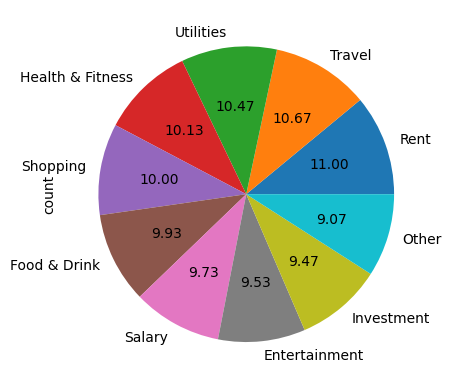

In [7]:
(df['Category']).value_counts().plot(kind='pie', autopct='%.2f')

<Axes: xlabel='count', ylabel='Type'>

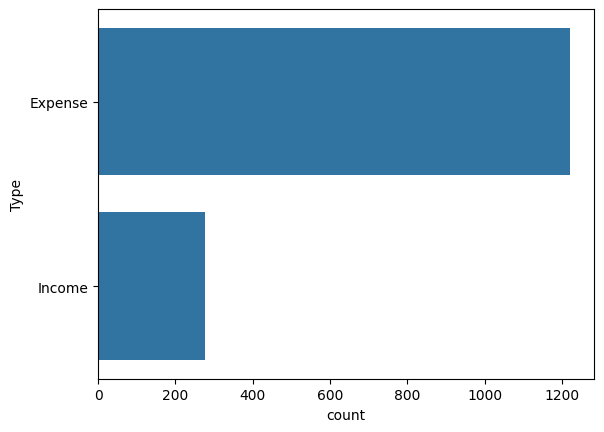

In [15]:
sns.countplot(df["Type"])

<Axes: ylabel='count'>

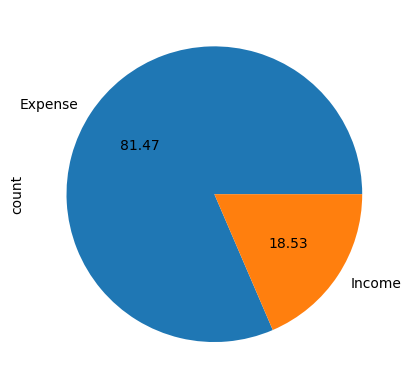

In [17]:
df['Type'].value_counts().plot(kind='pie', autopct='%.2f')

### EDA on DATEs

In [23]:
# step1: conversion
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     1500 non-null   datetime64[ns]
 1   Transaction Description  1500 non-null   object        
 2   Category                 1500 non-null   object        
 3   Amount                   1500 non-null   float64       
 4   Type                     1500 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 58.7+ KB


In [27]:
# step2: Basic Checks

# a.
df['Date'].min()

Timestamp('2020-01-02 00:00:00')

In [28]:
df['Date'].max()

Timestamp('2024-12-29 00:00:00')

This consists of finance data over the 5 years!

<Axes: ylabel='count'>

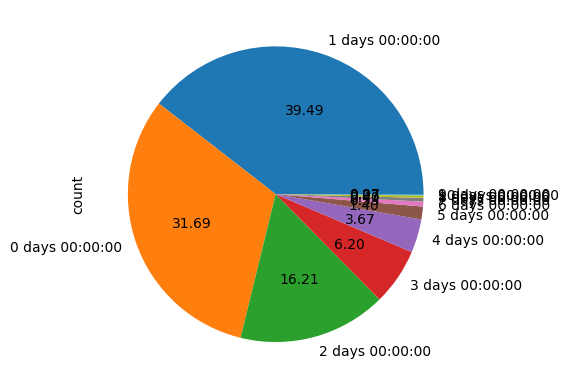

In [40]:
df['Date'].diff(periods=1).value_counts().plot(kind='pie', autopct='%.2f', startangle=0) # gaps

In [43]:
values = df['Date'].diff(periods=1).value_counts().tolist()
values

[592, 475, 243, 93, 55, 21, 8, 6, 4, 1, 1]

In [46]:
threshold = 100
explode = [0 if v > threshold else 0.3 for v in values]

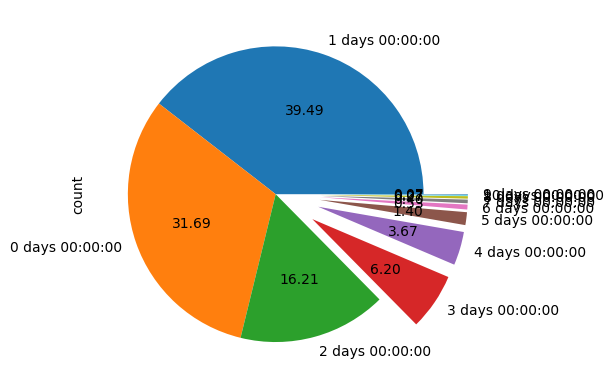

In [ ]:
df['Date'].diff(periods=1).value_counts().plot(kind='pie', autopct='%.2f', explode=explode)

In [32]:
df['Date'].diff()

0         NaT
1      0 days
2      2 days
3      1 days
4      8 days
        ...  
1495   5 days
1496   0 days
1497   0 days
1498   1 days
1499   0 days
Name: Date, Length: 1500, dtype: timedelta64[ns]